# QUMMSA

Este algoritmo consiste en hallar el valor máximo o mínimo utilizando Grover Long y el modelo de Durr Hoyer para encontrar con precisión un resultado.

En el presente cuaderno, veremos la implementación, paso a paso, del algoritmo en cuestión. Procurando conservar los mismos nombres de variables para no desviar la comprensión del paper.

Lo principal, importar los paquetes correspondientes para la implementación en IBM Qiskit en Python 3.12.0

In [42]:
import qiskit
import numpy as np
from qiskit import QuantumCircuit
import matplotlib.pyplot as plt
import qiskit_aer


## Algoritmo basico
En este ejemplo didáctico, vemos el algoritmo a un nivel meramente clásico que sirve para visualizar las iteraciones de la búsqueda siguiendo lo estipulado en el paper.
> Problem: Let 𝐷 be an unsorted database with 𝑁 items. The problem is to find the maximum or minimum from 𝐷 .

In [43]:
# Definiciones base
D_original = [ 23, 26, 60, 7, 9, 12, 15, 18]
N = len(D_original)

> Core idea: Exploiting the Grover-Long algorithm, we can find 𝑀(𝑀≥1) solutions from the unsorted database with 𝑁 items. Here, a random value 𝑑0 is taken as a reference value. If the search algorithm gives a result 𝑑1, which is less than or equals to 𝑑0, it will run successfully. Note that there are 𝑀 results that satisfy the search condition and 𝑑1 is one of them. Then, let 𝑑1 replace 𝑑0 and repeat the above steps until 𝑀=1. Since the 𝑀 solutions are given with equal probability after Grover-Long algorithm, the number of solutions will be reduced by half on average, after one main loop. Therefore, the mathematical expectation of main loops to find the minimum is log2𝑁, in theory.

A continuación se buscó interpretar el paper partiendo de lo enunciado en "Core idea", utilizando M=1 como condición de parada.

In [9]:
def function_qmin_M_based(D_original):
    D = D_original
    d_0 = np.random.choice(D)
    d = [] 
    M = N
    # M = len(d)
    while M > 1:
        d = []
        for i in D:
            if i <= d_0:
                d.append(i)
        M = len(d)
        print(M)
        d_1 = np.random.choice(d)
        d_0 = d_1

function_qmin_M_based(D_original)

5
3
1


A continuación, intenté recrear el pseudocódigo del paper, sin embargo después de corregir la posición dentro del while de d_1 = 999, sigo sin entender por qué la condición de parada es c y con qué c quedarnos.

## Condición de parada "c"
Surgen dudas con respecto a la condición de parada c, ya que es independiente del tamaño de la base de datos y parece requerir iteraciones adicionales.

### Explicación Claude Sonnet 4.6:
*`c` es independiente de N — esa es una ventaja clave del algoritmo*

El paper (Sección 5.1) razona así:

Cuando `d_0` es el verdadero mínimo ($r_0 = 1$, solo hay un elemento marcado), Grover-Long siempre retorna `d_0`. Pero si **no** es el mínimo y $r_0 = 2$ (hay exactamente un elemento menor), la probabilidad de que igualmente retorne `d_0` (y te "engañe") es $\frac{1}{r_0} = \frac{1}{2}$.

La probabilidad de ser engañado `c` veces consecutivas es:

$$P(\text{fallo}) \leq \left(\frac{1}{r_0}\right)^c \leq \left(\frac{1}{2}\right)^c \quad \text{(peor caso: } r_0 = 2\text{)}$$

Por tanto, dado un nivel de confianza deseado, despejando `c`:

$$c \geq \log_2\!\left(\frac{1}{\varepsilon}\right)$$

| `c` | Prob. de éxito | Prob. de fallo |
|-----|----------------|----------------|
| 4  | 93.75%         | 6.25%          |
| 7  | 99.22%         | 0.78%          |
| 10 | 99.90%         | 0.10%          |
| 14 | 99.99%         | 0.01%          |

**Lo relevante:** el paper señala esto como una mejora sobre DHA, cuya condición de parada era $O(\log N)$, haciéndola dependiente del tamaño de la base de datos. Aquí `c` es una constante que eliges según la confianza que necesites, **sin importar cuántos elementos tenga D**.

> _¿Pero eso aumenta la cantidad de veces que se ejecuta Grover Long?_

Exactamente, y el paper lo reconoce explícitamente. En la complejidad total (ecuación 21) el término `c` aparece de forma **aditiva**:

$$R = \frac{\frac{\pi}{2}(2 + \sqrt{2} + c)\sqrt{N} + (\log_2 N + c)\log_2 N}{1 - \varepsilon}$$

Pero el trade-off es favorable por dos razones:

**1. Las `c` ejecuciones extra son las más baratas**

Ocurren cuando `d_1 = d_0`, es decir cuando $M = 1$. Con $M/N \approx 1/2^n$, el número de iteraciones de Grover-Long es mínimo ($J = 1$), así que son los circuitos más cortos de toda la ejecución.

**2. La confianza crece exponencialmente, el coste crece linealmente**

| Coste adicional (`c` ejecuciones extra) | Confianza ganada |
|---|---|
| +3 ejecuciones (c: 7→10) | 99.22% → 99.90% |
| +10 ejecuciones (c: 7→17) | 99.22% → 99.999% |

**3. Es mejor que DHA**

La condición de parada de DHA dependía de $O(\log N)$, lo que significa que al doblar el tamaño de la base de datos, el coste de parada también crece. Con `c` constante, ese coste **no escala con N**.

En la Fig. 15 del paper muestran que para $N$ grande QUMMSA sigue siendo más eficiente que DHA, incluso con el coste de las `c` iteraciones adicionales.

## Algoritmo del pseudocódigo
En esta parte se buscó la implementación fiel del pseudocódigo del paper (página 4). Siguiendo los pasos se descubrió que la declaración de $d_1=+\infty$ estaba mal ubicada fuera del ciclo for, en nuestra implementación esta definición calza dentro de dicho ciclo, permitiendo el reinicio de dicha variable en cada iteración del ciclo for, de lo contrario $d_1$ queda con el último valor medido por el componente cuántico y no pasa nuevamente por el oráculo.

In [30]:
# Definiciones base
def infinity():
    return 99999999

def quantum_search_classic_simulation(D, d_0):
    d = []
    for j in D:
        if j <= d_0:
            d.append(j)
    d_1 = np.random.choice(d)
    print(d_1, d) # -> min [list]
    return d_1

##Siendo estrictos:
def funcion_qmin(D, d_0):
    c = 4
    i = 0
    # Ciclo for se adapta a un while para poder reiniciar el contador i en caso de que se encuentre un nuevo mínimo
    while i < c: 
        d_1 = infinity()
        while d_1 > d_0:
            d_1 = quantum_search_classic_simulation(D, d_0)
        if d_1 < d_0:
            i=0
        else:
            i += 1
        d_0 = d_1
        print("iter i:" , i)
    return d_0


In [37]:
# Ejecución de la función
D = D_original
d_0 = np.random.choice(D)
d_0= funcion_qmin(D, d_0)
print("Valor:              ", d_0)
    

23 [23, 7, 9, 12, 15, 18]
iter i: 1
18 [23, 7, 9, 12, 15, 18]
iter i: 0
9 [7, 9, 12, 15, 18]
iter i: 0
7 [7, 9]
iter i: 0
7 [7]
iter i: 1
7 [7]
iter i: 2
7 [7]
iter i: 3
7 [7]
iter i: 4
Valor:               7


El resultado es correcto y refleja fielmente el comportamiento descrito en el paper. 

Ejemplo: Desglosando la ejecución tenemos la siguiente tabla.

| Paso | `d_0` | `d` (oráculo ≤ d_0) | `d_1` obtenido | `i` |
|------|--------|----------------------|----------------|-----|
| 1 | 60 | todos los 8 elementos | 26 | reset → 0 |
| 2 | 26 | [23,26,7,9,12,15,18] | 18 | reset → 0 |
| 3 | 18 | [7,9,12,15,18] | 7 | reset → 0 |
| 4-7 | 7 | [7] | 7 (único) | 1 → 2 → 3 → 4 |

**Lo que confirma que está bien:**

- Cuando `d_0 = 7` (mínimo real), el oráculo marca solo `{7}` → $M = 1$
- Grover-Long con $M=1$ siempre retorna `d_0`, por lo que `d_1 = d_0` cada vez
- El contador `i` sube consecutivamente hasta `c=4`, confirmando que es el mínimo
- La confianza obtenida es $1 - (1/2)^4 = 93.75\%$

Sobre el valor de `c`: el paper lo deja como parámetro libre. Con `c=4` se obtiene un 93.75% de probabilidad de éxito; con `c=10` se tendría ~99.9%. Ciendo el coste `c` ejecuciones adicionales del algoritmo cuántico.

## Codificación cuántica
En esta sección preparamos el operador $W$ que construye el estado inicial del paper usando 6 qubits. Cada valor $x \in D$ se codifica como el estado base $|x\rangle$ en binario de 6 bits y el registro completo queda en la superposición:

$$|\Psi_D\rangle = \frac{1}{\sqrt{N}}\sum_{x \in D}|x\rangle$$

Así, los $N$ datos tienen amplitud uniforme $1/\sqrt{N}$ y los demás estados de la base computacional mantienen amplitud 0, tal como plantea la hipótesis (6) del paper.

> (1) Each data value is represented by a binary string and is stored in an orthonormal basis state of |Ø>., where |Ø>. is the initial state. Therefore, the data value lies in interval [0,2^n - 1], where n is the number of qubits.<br>
> (2) There is a one-to-one mapping between a data value and its index. The index may be a person's name or other non-numeric data.

In [47]:
# Codificación de los datos de D en 6 qubits
D = D_original
N = len(D)
n_qubits = 6

if max(D) >= 2**n_qubits:
    raise ValueError("Hay valores en D que no caben en 6 qubits.")

# Cada valor clásico se representa como un estado base de 6 bits
D_bin = [format(valor, f"0{n_qubits}b") for valor in D]
indices_codificados = [int(bits, 2) for bits in D_bin]

print(f"Número de datos en D: {N}")
print(f"Número de qubits usados: {n_qubits}")
for idx, (valor, bits) in enumerate(zip(D, D_bin)):
    print(f"Índice {idx}: {valor} -> |{bits}>")

Número de datos en D: 8
Número de qubits usados: 6
Índice 0: 23 -> |010111>
Índice 1: 26 -> |011010>
Índice 2: 60 -> |111100>
Índice 3: 7 -> |000111>
Índice 4: 9 -> |001001>
Índice 5: 12 -> |001100>
Índice 6: 15 -> |001111>
Índice 7: 18 -> |010010>


Norma del estado: 1.000000
Amplitud esperada para cada dato codificado: 0.353553
Estados de D con amplitud uniforme: True
Estados no usados con amplitud cero: True
23 -> |010111> : amplitud = (0.35355339059327373+0j)
26 -> |011010> : amplitud = (0.35355339059327373+0j)
60 -> |111100> : amplitud = (0.35355339059327373+0j)
 7 -> |000111> : amplitud = (0.35355339059327373+0j)
 9 -> |001001> : amplitud = (0.35355339059327373+0j)
12 -> |001100> : amplitud = (0.35355339059327373+0j)
15 -> |001111> : amplitud = (0.35355339059327373+0j)
18 -> |010010> : amplitud = (0.35355339059327373+0j)
Ejemplo de estado no usado |000000>:  0j


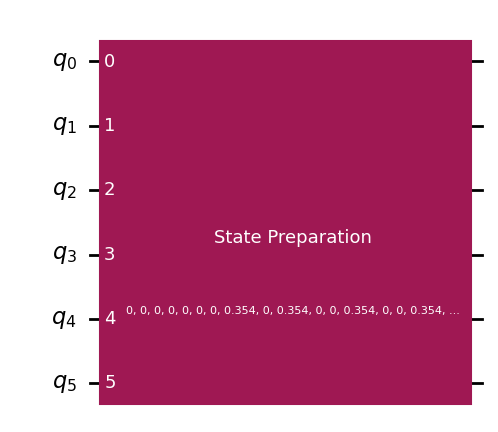

In [53]:
from qiskit.circuit.library import StatePreparation
from qiskit.quantum_info import Statevector

# Estado |Psi_D> = (1/sqrt(N)) * sum_x |x> para x en D
amplitudes = np.zeros(2**n_qubits, dtype=complex)
amplitud_objetivo = 1 / np.sqrt(N)
amplitudes[indices_codificados] = amplitud_objetivo

psi_D = Statevector(amplitudes)

# W prepara el estado inicial que usaremos más adelante en Grover-Long
W = StatePreparation(amplitudes)
qc_W = QuantumCircuit(n_qubits, name="W")
qc_W.append(W, range(n_qubits))

indices_no_codificados = sorted(set(range(2**n_qubits)) - set(indices_codificados))

print(f"Norma del estado: {np.linalg.norm(amplitudes):.6f}")
print(f"Amplitud esperada para cada dato codificado: {amplitud_objetivo:.6f}")
print(
    "Estados de D con amplitud uniforme:",
    np.allclose(psi_D.data[indices_codificados], amplitud_objetivo + 0j),
)
print(
    "Estados no usados con amplitud cero:",
    np.allclose(psi_D.data[indices_no_codificados], 0.0 + 0j),
)

for valor, bits, indice in zip(D, D_bin, indices_codificados):
    print(f"{valor:>2} -> |{bits}> : amplitud = {psi_D.data[indice]}")

primer_estado_no_usado = indices_no_codificados[0]
print(
    f"Ejemplo de estado no usado |{primer_estado_no_usado:06b}>: ",
    psi_D.data[primer_estado_no_usado],
)

qc_W.draw("mpl", fold=-1);

Conteos medidos (1000 shots):
{'000111': 130, '001001': 123, '001100': 114, '001111': 124, '010010': 114, '010111': 130, '011010': 149, '111100': 116}


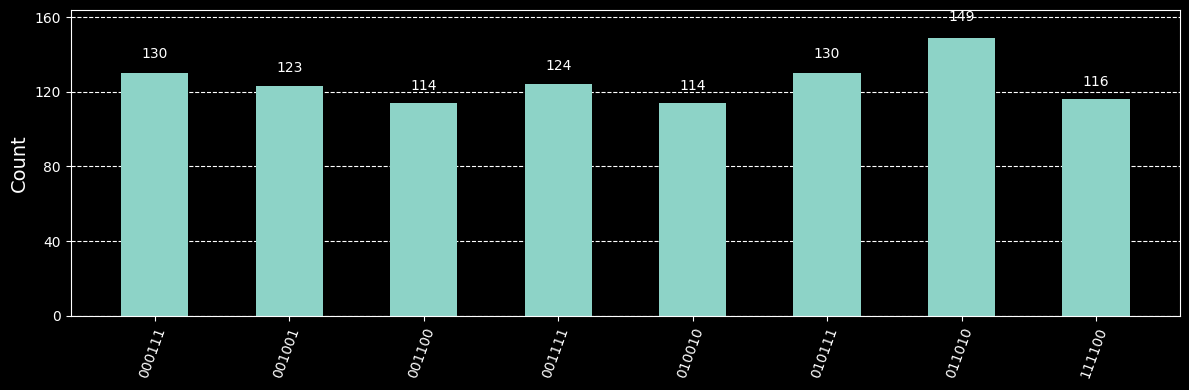

In [52]:
from qiskit.visualization import plot_histogram

# Medición del estado preparado con 1000 shots
qc_medicion = qc_W.copy()
qc_medicion.measure_all()

simulador = qiskit_aer.AerSimulator()
qc_compilado = qiskit.transpile(qc_medicion, simulador)
resultado = simulador.run(qc_compilado, shots=1000).result()
conteos = resultado.get_counts()

print("Conteos medidos (1000 shots):")
print(dict(sorted(conteos.items())))

plot_histogram(conteos, figsize=(12, 4));